# Laboratorio 04 - Ejercicio 2

## Selección de Portafolios

Problema: distribuir una cantidad total C en n opciones de inversión con rendimiento esperado ri.

## 1) Representación del problema como búsqueda

Espacio de configuraciones Omega:
Omega = { x = (x1, x2, ..., xn) | xi >= 0 entero, suma xi = U }
donde U es la cantidad total en unidades discretas (por ejemplo bloques de Q quetzales)

Tamaño de Omega:
|Ω| = C(U + n - 1, n - 1)
(fórmula de combinaciones con repeticion, stars and bars)

Descripción de configuraciones:
Cada configuración es un vector entero x de longitud n con la cantidad invertida en cada opción

Funcion de costo / objetivo:
Maximizar retorno esperado R(x) = suma(xi * ri)
Equivalente en minimización: minimizar f(x) = -R(x)

In [13]:
from itertools import product
from math import comb

n = 4
asset_names = ["A", "B", "C", "D"]
returns = [0.08, 0.12, 0.10, 0.15]  #ri por unidad
U = 10  #unidades totales a invertir

omega_size = comb(U + n - 1, n - 1)

print(f"Numero de activos n: {n}")
print(f"Unidades totales U: {U}")
print(f"Tamaño de Ω = C(U+n-1, n-1) = {omega_size}")
print("Activos y rendimiento esperado:")
for name, r in zip(asset_names, returns):
    print(f"  {name}: r={r}")

Numero de activos n: 4
Unidades totales U: 10
Tamaño de Ω = C(U+n-1, n-1) = 286
Activos y rendimiento esperado:
  A: r=0.08
  B: r=0.12
  C: r=0.1
  D: r=0.15


In [14]:
def expected_return(config, r):
    return sum(xi * ri for xi, ri in zip(config, r))


def generate_all_configs(num_assets, total_units):
    #numeracion completa de vectores enteros no negativos que suman total_units
    configs = []
    for x in product(range(total_units + 1), repeat=num_assets):
        if sum(x) == total_units:
            configs.append(x)
    return configs


def solve_portfolio_bruteforce(num_assets, total_units, r):
    configs = generate_all_configs(num_assets, total_units)

    best_cfg = None
    best_value = None

    for cfg in configs:
        value = expected_return(cfg, r)
        if (best_value is None) or (value > best_value):
            best_value = value
            best_cfg = cfg

    return configs, best_cfg, best_value

In [15]:
configs, best_config, best_value = solve_portfolio_bruteforce(n, U, returns)

print(f"Total de configuraciones generadas: {len(configs)}")
print(f"¿Coincide con fórmula combinatoria?: {len(configs) == omega_size}")

print("\nMejor configuración encontrada:")
for name, units in zip(asset_names, best_config):
    print(f"  {name}: {units} unidades")

print(f"Retorno esperado m+aximo: {best_value:.4f}")

assert sum(best_config) == U
assert len(best_config) == n
print("Prueba superada: la configuracion es valida y el codigo funciona.")

Total de configuraciones generadas: 286
¿Coincide con fórmula combinatoria?: True

Mejor configuración encontrada:
  A: 0 unidades
  B: 0 unidades
  C: 0 unidades
  D: 10 unidades
Retorno esperado m+aximo: 1.5000
Prueba superada: la configuracion es valida y el codigo funciona.


## 2) Gráfica del arbol de busqueda (primeros 3 niveles)

Para visualizar el proceso de busqueda, construimos un arbol de profundidad 3:
- Nivel 1: unidades para activo A (0, 1 o 2)
- Nivel 2: unidades para activo B (0, 1 o 2)
- Nivel 3: unidades para activo C (0, 1 o 2)

Cada camino parcial representa una asignacion parcial de inversion.

In [16]:
def build_three_level_tree(values=(0, 1, 2)):
    tree = {"label": "Inicio", "children": []}

    for a in values:
        node_a = {"label": f"A={a}", "children": []}
        tree["children"].append(node_a)
        for b in values:
            node_b = {"label": f"B={b}", "children": []}
            node_a["children"].append(node_b)
            for c in values:
                node_c = {"label": f"C={c}", "children": []}
                node_b["children"].append(node_c)

    return tree


def print_tree(node, indent=""):
    print(indent + node["label"])
    for child in node.get("children", []):
        print_tree(child, indent + "  ")


tree3 = build_three_level_tree(values=(0, 1, 2))
print("Arbol de busqueda (3 niveles, ramificacion 3):")
print_tree(tree3)

Arbol de busqueda (3 niveles, ramificacion 3):
Inicio
  A=0
    B=0
      C=0
      C=1
      C=2
    B=1
      C=0
      C=1
      C=2
    B=2
      C=0
      C=1
      C=2
  A=1
    B=0
      C=0
      C=1
      C=2
    B=1
      C=0
      C=1
      C=2
    B=2
      C=0
      C=1
      C=2
  A=2
    B=0
      C=0
      C=1
      C=2
    B=1
      C=0
      C=1
      C=2
    B=2
      C=0
      C=1
      C=2


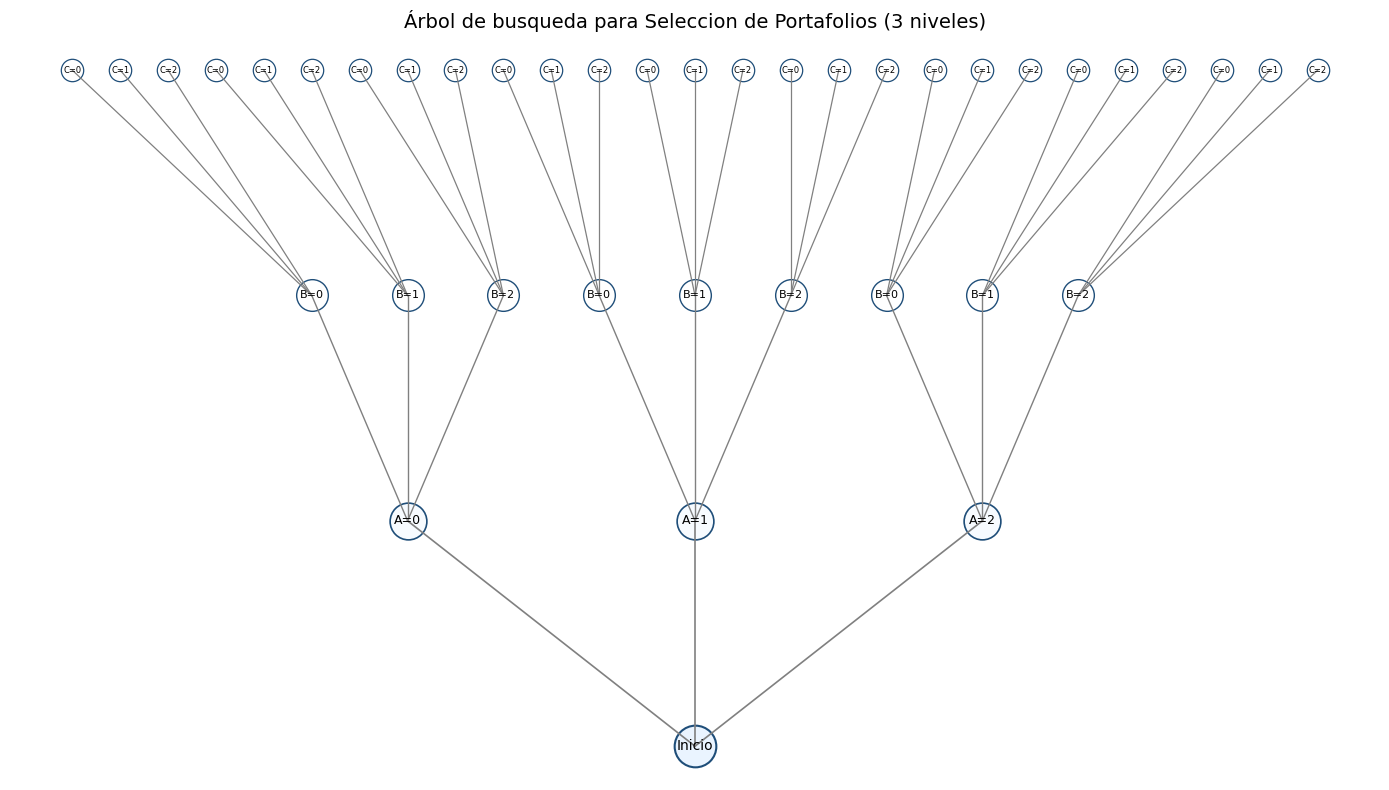

In [17]:
import matplotlib.pyplot as plt


def draw_portfolio_tree(values=(0, 1, 2)):
    fig, ax = plt.subplots(figsize=(14, 8))

    x_root = 0
    y_root = 0
    ax.scatter([x_root], [y_root], s=900, color="#EAF4FF", edgecolors="#1F4E79", linewidths=1.5)
    ax.text(x_root, y_root, "Inicio", ha="center", va="center", fontsize=10)

    x_lvl1 = [-6, 0, 6]
    y_lvl1 = 2
    x_lvl2 = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
    y_lvl2 = 4
    x_lvl3 = list(range(-13, 14))
    y_lvl3 = 6

    level1_nodes = []
    for i, a in enumerate(values):
        x = x_lvl1[i]
        label = f"A={a}"
        level1_nodes.append((x, label, a))
        ax.plot([x_root, x], [y_root, y_lvl1], color="gray", linewidth=1.2)
        ax.scatter([x], [y_lvl1], s=700, color="#F7FBFF", edgecolors="#1F4E79", linewidths=1.2)
        ax.text(x, y_lvl1, label, ha="center", va="center", fontsize=9)

    idx2 = 0
    level2_nodes = []
    for x_parent, _, a in level1_nodes:
        for b in values:
            x = x_lvl2[idx2]
            idx2 += 1
            label = f"B={b}"
            level2_nodes.append((x, label, a, b, x_parent))
            ax.plot([x_parent, x], [y_lvl1, y_lvl2], color="gray", linewidth=1.0)
            ax.scatter([x], [y_lvl2], s=520, color="#FFFFFF", edgecolors="#1F4E79", linewidths=1.0)
            ax.text(x, y_lvl2, label, ha="center", va="center", fontsize=8)

    idx3 = 0
    for x_parent, _, a, b, _ in level2_nodes:
        for c in values:
            x = x_lvl3[idx3]
            idx3 += 1
            label = f"C={c}"
            ax.plot([x_parent, x], [y_lvl2, y_lvl3], color="gray", linewidth=0.9)
            ax.scatter([x], [y_lvl3], s=260, color="#FFFFFF", edgecolors="#1F4E79", linewidths=0.9)
            ax.text(x, y_lvl3, label, ha="center", va="center", fontsize=6)

    ax.set_title("Árbol de busqueda para Seleccion de Portafolios (3 niveles)", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


draw_portfolio_tree(values=(0, 1, 2))

## 3) Conclusiones

- El problema se fórmula como busqueda sobre vectores de asignación que suman U
- El espacio de busqueda tiene tamano combinatorio C(U+n-1, n-1)
- La función objetivo es maximizar retorno esperado
- El árbol de búsqueda muestra decisiones parciales de asignación por niveles